In [1]:
# ============================================================================
# IMPORTS & SETUP
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    classification_report, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: sklearn.__version__")

✓ All libraries imported successfully
NumPy version: 2.1.3
Pandas version: 2.2.3
Scikit-learn version: sklearn.__version__


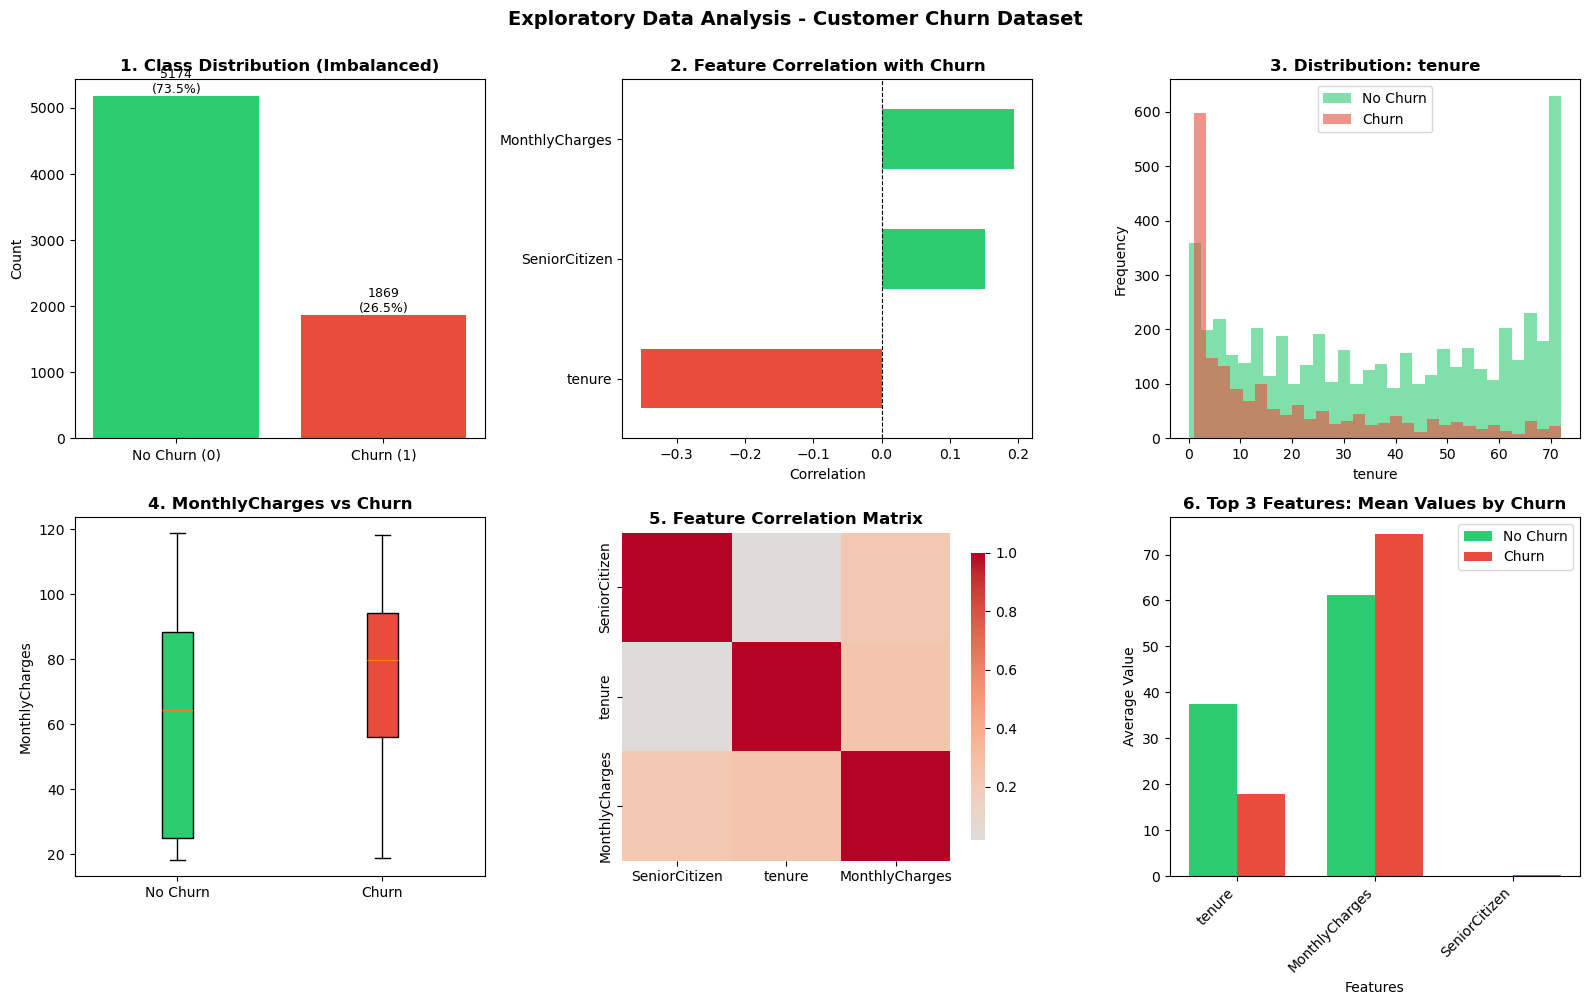


✓ EDA visualizations generated successfully


In [3]:
# ============================================================================
# EDA: Visual Analysis
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis - Customer Churn Dataset', 
             fontsize=14, fontweight='bold', y=1.00)

# 1. Class Distribution
ax = axes[0, 0]
churn_counts = df['churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=colors)
ax.set_ylabel('Count')
ax.set_title('1. Class Distribution (Imbalanced)', fontweight='bold')
for bar, val in zip(bars, churn_counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

# 2. Feature Correlation with Target
ax = axes[0, 1]
corr_with_target = df.corr()['churn'].drop('churn').sort_values()
corr_with_target.plot(kind='barh', ax=ax, color=['#e74c3c' if x < 0 else '#2ecc71' for x in corr_with_target])
ax.set_title('2. Feature Correlation with Churn', fontweight='bold')
ax.set_xlabel('Correlation')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# 3. Distribution of Top Feature (most correlated with churn)
ax = axes[0, 2]
top_feature = corr_with_target.abs().idxmax()  # Find most correlated feature
ax.hist(df[df['churn']==0][top_feature], bins=30, alpha=0.6, label='No Churn', color='#2ecc71')
ax.hist(df[df['churn']==1][top_feature], bins=30, alpha=0.6, label='Churn', color='#e74c3c')
ax.set_xlabel(top_feature)
ax.set_ylabel('Frequency')
ax.set_title(f'3. Distribution: {top_feature}', fontweight='bold')
ax.legend()

# 4. Box plot - Top Feature by Churn
ax = axes[1, 0]
second_feature = corr_with_target.abs().nlargest(2).index[1]  # Second most correlated feature
data_to_plot = [df[df['churn']==0][second_feature], df[df['churn']==1][second_feature]]
bp = ax.boxplot(data_to_plot, labels=['No Churn', 'Churn'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel(second_feature)
ax.set_title(f'4. {second_feature} vs Churn', fontweight='bold')

# 5. Feature Correlation Heatmap
ax = axes[1, 1]
corr_matrix = df[feature_names].corr()
sns.heatmap(corr_matrix, ax=ax, cmap='coolwarm', center=0, square=True, 
            cbar_kws={'shrink': 0.8}, annot=False)
ax.set_title('5. Feature Correlation Matrix', fontweight='bold')

# 6. Top 3 Features vs Churn (bar chart)
ax = axes[1, 2]
top_3_features = corr_with_target.abs().nlargest(3).index.tolist()
churn_means = [df.groupby('churn')[feat].mean() for feat in top_3_features]
positions = np.arange(len(top_3_features))
width = 0.35
for i, (pos, feat, means) in enumerate(zip(positions, top_3_features, churn_means)):
    ax.bar(pos - width/2, means[0], width, label='No Churn' if i == 0 else '', color='#2ecc71')
    ax.bar(pos + width/2, means[1], width, label='Churn' if i == 0 else '', color='#e74c3c')
ax.set_xlabel('Features')
ax.set_ylabel('Average Value')
ax.set_title('6. Top 3 Features: Mean Values by Churn', fontweight='bold')
ax.set_xticks(positions)
ax.set_xticklabels(top_3_features, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

print("\n✓ EDA visualizations generated successfully")

In [4]:
# ============================================================================
# PREPROCESSING: Feature Scaling & Train-Test Split
# ============================================================================

print("=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

# Separate features and target
X = df[feature_names].values
y = df['churn'].values

# Train-Test Split (80-20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set shape: {X_train_raw.shape}")
print(f"Test set shape: {X_test_raw.shape}")
print(f"\nTrain set class distribution:")
print(f"  No Churn: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Churn: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

# Standardize features using Z-score normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Verify scaling
print(f"\n✓ Features scaled successfully")
print(f"Train set - Mean: {X_train.mean(axis=0).round(4).mean():.6f}, Std: {X_train.std(axis=0).round(4).mean():.4f}")
print(f"Test set - Mean: {X_test.mean(axis=0).round(4).mean():.6f}, Std: {X_test.std(axis=0).round(4).mean():.4f}")

# Add bias term (intercept)
X_train_with_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_with_bias = np.c_[np.ones(X_test.shape[0]), X_test]

print(f"\n✓ Bias term added")
print(f"X_train shape with bias: {X_train_with_bias.shape}")
print(f"X_test shape with bias: {X_test_with_bias.shape}")

DATA PREPROCESSING

Train set shape: (5634, 3)
Test set shape: (1409, 3)

Train set class distribution:
  No Churn: 4139 (73.5%)
  Churn: 1495 (26.5%)

✓ Features scaled successfully
Train set - Mean: 0.000000, Std: 1.0000
Test set - Mean: -0.022200, Std: 0.9918

✓ Bias term added
X_train shape with bias: (5634, 4)
X_test shape with bias: (1409, 4)


SIGMOID FUNCTION VERIFICATION

Input values: [-5 -2  0  2  5]
Sigmoid outputs: [0.0067 0.1192 0.5    0.8808 0.9933]

Expected patterns:
  σ(-∞) → 0, σ(0) = 0.5, σ(+∞) → 1
  ✓ Sigmoid correctly maps to [0, 1] range


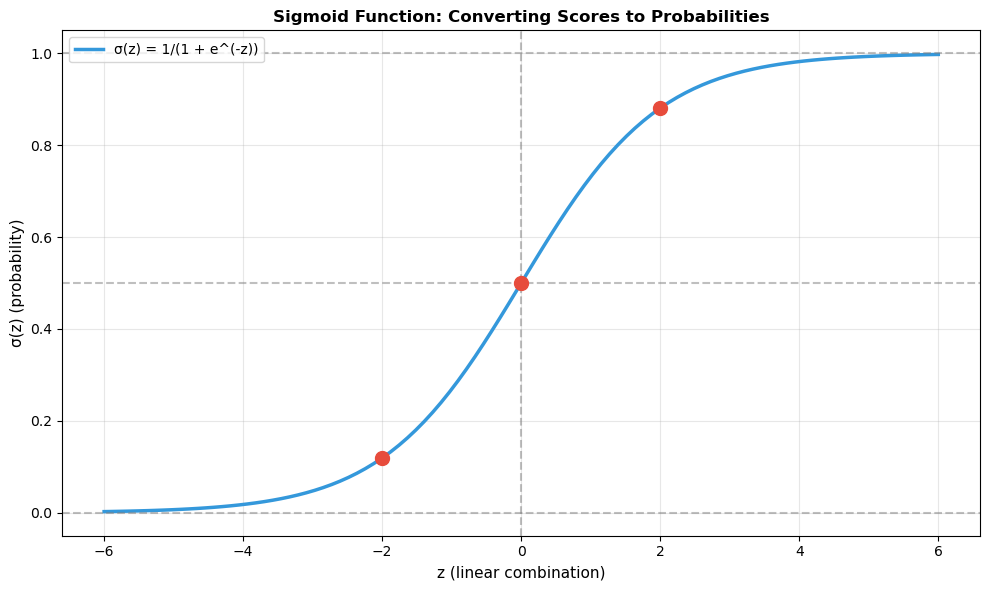


✓ Sigmoid function visualization complete


In [5]:
# ============================================================================
# IMPLEMENT: Sigmoid Function
# ============================================================================

def sigmoid(z):
    """
    Sigmoid activation function.
    
    σ(z) = 1 / (1 + e^(-z))
    
    Args:
        z: Linear combination (W^T @ X + b)
    
    Returns:
        Probability between 0 and 1
    """
    # Clip to avoid overflow
    z_clipped = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z_clipped))

# Test sigmoid function
print("=" * 70)
print("SIGMOID FUNCTION VERIFICATION")
print("=" * 70)

# Test cases
test_values = np.array([-5, -2, 0, 2, 5])
sigmoid_outputs = sigmoid(test_values)

print(f"\nInput values: {test_values}")
print(f"Sigmoid outputs: {sigmoid_outputs.round(4)}")
print(f"\nExpected patterns:")
print(f"  σ(-∞) → 0, σ(0) = 0.5, σ(+∞) → 1")
print(f"  ✓ Sigmoid correctly maps to [0, 1] range")

# Visualize sigmoid
z_range = np.linspace(-6, 6, 100)
sigmoid_curve = sigmoid(z_range)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(z_range, sigmoid_curve, linewidth=2.5, label='σ(z) = 1/(1 + e^(-z))', color='#3498db')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.scatter([-2, 0, 2], sigmoid(np.array([-2, 0, 2])), color='#e74c3c', s=100, zorder=5)
ax.set_xlabel('z (linear combination)', fontsize=11)
ax.set_ylabel('σ(z) (probability)', fontsize=11)
ax.set_title('Sigmoid Function: Converting Scores to Probabilities', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([-0.05, 1.05])
plt.tight_layout()
plt.show()

print("\n✓ Sigmoid function visualization complete")

LOG-LOSS FUNCTION VERIFICATION

Test Case 1: Perfect Prediction
  True labels: [0 0 1 1]
  Predicted probs: [0.01 0.02 0.99 0.98]
  Log-loss: 0.0151 (Low ✓)

Test Case 2: Wrong Prediction
  True labels: [0 0 1 1]
  Predicted probs: [0.98 0.99 0.01 0.02]
  Log-loss: 4.2586 (High ✓)

Test Case 3: Random Guessing (p=0.5)
  True labels: [0 0 1 1]
  Predicted probs: [0.5 0.5 0.5 0.5]
  Log-loss: 0.6931 (Baseline ✓)


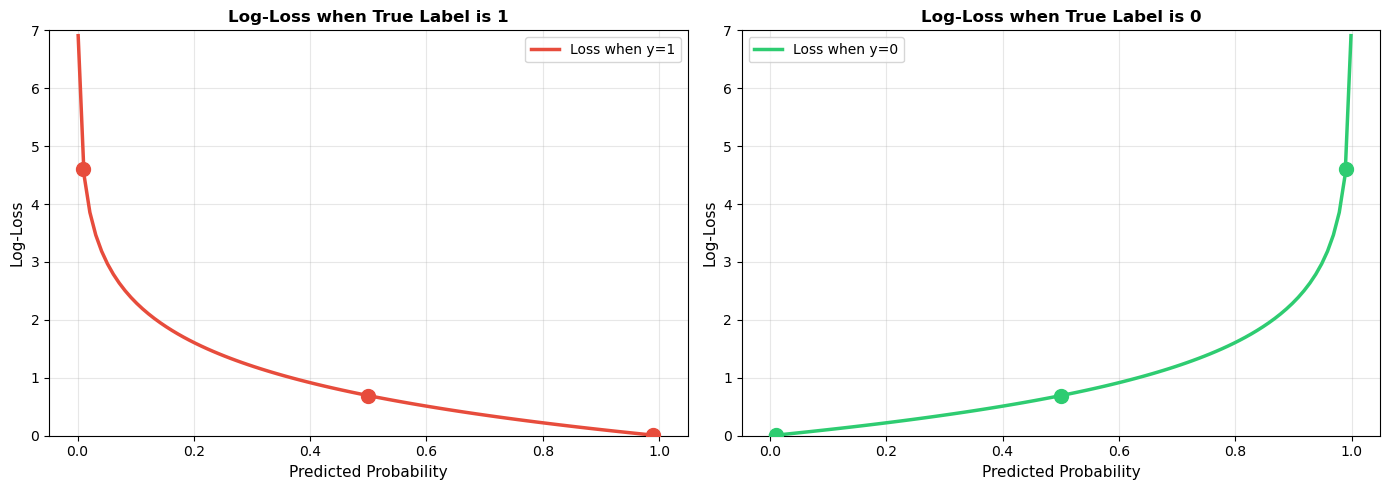


✓ Log-loss function visualization complete


In [6]:
# ============================================================================
# IMPLEMENT: Log-Loss (Cross-Entropy) Function
# ============================================================================

def compute_log_loss(y, y_pred, epsilon=1e-15):
    """
    Compute binary cross-entropy loss.
    
    L = -(1/m) * Σ[y*log(ŷ) + (1-y)*log(1-ŷ)]
    
    Args:
        y: True labels (0 or 1)
        y_pred: Predicted probabilities [0, 1]
        epsilon: Small value to prevent log(0)
    
    Returns:
        Average log-loss
    """
    # Clip predictions to prevent log(0)
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    
    # Binary cross-entropy formula
    loss = -(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
    
    return loss.mean()

# Test log-loss function
print("=" * 70)
print("LOG-LOSS FUNCTION VERIFICATION")
print("=" * 70)

# Test Case 1: Perfect predictions
y_true = np.array([0, 0, 1, 1])
y_pred_perfect = np.array([0.01, 0.02, 0.99, 0.98])
loss_perfect = compute_log_loss(y_true, y_pred_perfect)

print(f"\nTest Case 1: Perfect Prediction")
print(f"  True labels: {y_true}")
print(f"  Predicted probs: {y_pred_perfect}")
print(f"  Log-loss: {loss_perfect:.4f} (Low ✓)")

# Test Case 2: Very wrong predictions
y_pred_wrong = np.array([0.98, 0.99, 0.01, 0.02])
loss_wrong = compute_log_loss(y_true, y_pred_wrong)

print(f"\nTest Case 2: Wrong Prediction")
print(f"  True labels: {y_true}")
print(f"  Predicted probs: {y_pred_wrong}")
print(f"  Log-loss: {loss_wrong:.4f} (High ✓)")

# Test Case 3: Random guessing
y_pred_random = np.array([0.5, 0.5, 0.5, 0.5])
loss_random = compute_log_loss(y_true, y_pred_random)

print(f"\nTest Case 3: Random Guessing (p=0.5)")
print(f"  True labels: {y_true}")
print(f"  Predicted probs: {y_pred_random}")
print(f"  Log-loss: {loss_random:.4f} (Baseline ✓)")

# Visualize how loss changes with prediction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# For positive class (y=1)
pred_range = np.linspace(0.001, 0.999, 100)
loss_positive = -np.log(pred_range)

ax1.plot(pred_range, loss_positive, linewidth=2.5, label='Loss when y=1', color='#e74c3c')
ax1.scatter([0.01, 0.5, 0.99], [-np.log(0.01), -np.log(0.5), -np.log(0.99)], 
            color='#e74c3c', s=100, zorder=5)
ax1.set_xlabel('Predicted Probability', fontsize=11)
ax1.set_ylabel('Log-Loss', fontsize=11)
ax1.set_title('Log-Loss when True Label is 1', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 7])
ax1.legend(fontsize=10)

# For negative class (y=0)
loss_negative = -np.log(1 - pred_range)

ax2.plot(pred_range, loss_negative, linewidth=2.5, label='Loss when y=0', color='#2ecc71')
ax2.scatter([0.01, 0.5, 0.99], [-np.log(0.99), -np.log(0.5), -np.log(0.01)], 
            color='#2ecc71', s=100, zorder=5)
ax2.set_xlabel('Predicted Probability', fontsize=11)
ax2.set_ylabel('Log-Loss', fontsize=11)
ax2.set_title('Log-Loss when True Label is 0', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 7])
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Log-loss function visualization complete")

In [7]:
# ============================================================================
# IMPLEMENT: Gradient Descent Optimization
# ============================================================================

class CustomLogisticRegression:
    """
    Binary Logistic Regression Classifier implemented from scratch using NumPy.
    """
    
    def __init__(self, learning_rate=0.01, iterations=1000, class_weight='balanced'):
        """
        Initialize logistic regression.
        
        Args:
            learning_rate: Step size for gradient descent
            iterations: Number of iterations to train
            class_weight: 'balanced' to handle class imbalance, None otherwise
        """
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.class_weight = class_weight
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.class_weights = None
    
    def fit(self, X, y):
        """
        Train the logistic regression model using gradient descent.
        
        Args:
            X: Feature matrix (m, n) where m=samples, n=features
            y: Target labels (m,)
        """
        m, n = X.shape
        
        # Initialize weights and bias
        self.weights = np.zeros(n)
        self.bias = 0
        
        # Compute class weights if balancing is requested
        if self.class_weight == 'balanced':
            unique_classes = np.unique(y)
            self.class_weights = compute_class_weight('balanced', 
                                                       classes=unique_classes, 
                                                       y=y)
            # Map to dict: {class: weight}
            self.class_weights = {0: self.class_weights[0], 1: self.class_weights[1]}
            print(f"\n✓ Class weights computed: {self.class_weights}")
        else:
            self.class_weights = {0: 1.0, 1: 1.0}
        
        # Gradient Descent
        for iteration in range(self.iterations):
            # Predictions
            z = np.dot(X, self.weights) + self.bias
            h = sigmoid(z)  # Probability predictions
            
            # Weighted errors
            errors = h - y
            weighted_errors = errors.copy()
            
            # Apply class weights
            weighted_errors[y == 0] *= self.class_weights[0]
            weighted_errors[y == 1] *= self.class_weights[1]
            
            # Gradient computation
            dw = (1/m) * np.dot(X.T, weighted_errors)
            db = (1/m) * np.sum(weighted_errors)
            
            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Compute loss for monitoring
            if self.class_weight == 'balanced':
                # Weighted loss
                sample_weights = np.array([self.class_weights[int(label)] for label in y])
                weighted_loss = compute_log_loss(y, h) * sample_weights.mean()
                loss = weighted_loss
            else:
                loss = compute_log_loss(y, h)
            
            self.loss_history.append(loss)
            
            # Print progress
            if (iteration + 1) % (self.iterations // 10) == 0 or iteration == 0:
                print(f"  Iteration {iteration+1:4d}/{self.iterations} | Loss: {loss:.6f}")
        
        return self
    
    def predict_proba(self, X):
        """
        Predict probability of class 1.
        
        Args:
            X: Feature matrix
        
        Returns:
            Predicted probabilities
        """
        z = np.dot(X, self.weights) + self.bias
        return sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """
        Predict class labels.
        
        Args:
            X: Feature matrix
            threshold: Decision threshold (default 0.5)
        
        Returns:
            Predicted class labels (0 or 1)
        """
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

print("=" * 70)
print("CUSTOM LOGISTIC REGRESSION IMPLEMENTATION COMPLETE")
print("=" * 70)
print("\n✓ Class definition loaded successfully")

CUSTOM LOGISTIC REGRESSION IMPLEMENTATION COMPLETE

✓ Class definition loaded successfully


## 8. Train Custom Logistic Regression Model

TRAINING CUSTOM LOGISTIC REGRESSION MODEL

Model Configuration:
  - Learning Rate: 0.01
  - Iterations: 1000
  - Class Weight: Balanced
  - Input Shape: (5634, 4)

Starting gradient descent training...

✓ Class weights computed: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}
  Iteration    1/1000 | Loss: 0.693147
  Iteration  100/1000 | Loss: 0.655669
  Iteration  200/1000 | Loss: 0.628746
  Iteration  300/1000 | Loss: 0.609146
  Iteration  400/1000 | Loss: 0.594535
  Iteration  500/1000 | Loss: 0.583408
  Iteration  600/1000 | Loss: 0.574776
  Iteration  700/1000 | Loss: 0.567968
  Iteration  800/1000 | Loss: 0.562525
  Iteration  900/1000 | Loss: 0.558120
  Iteration 1000/1000 | Loss: 0.554518

✓ Training completed successfully
  Final Loss: 0.554518
  Initial Loss: 0.693147
  Loss Reduction: 20.00%


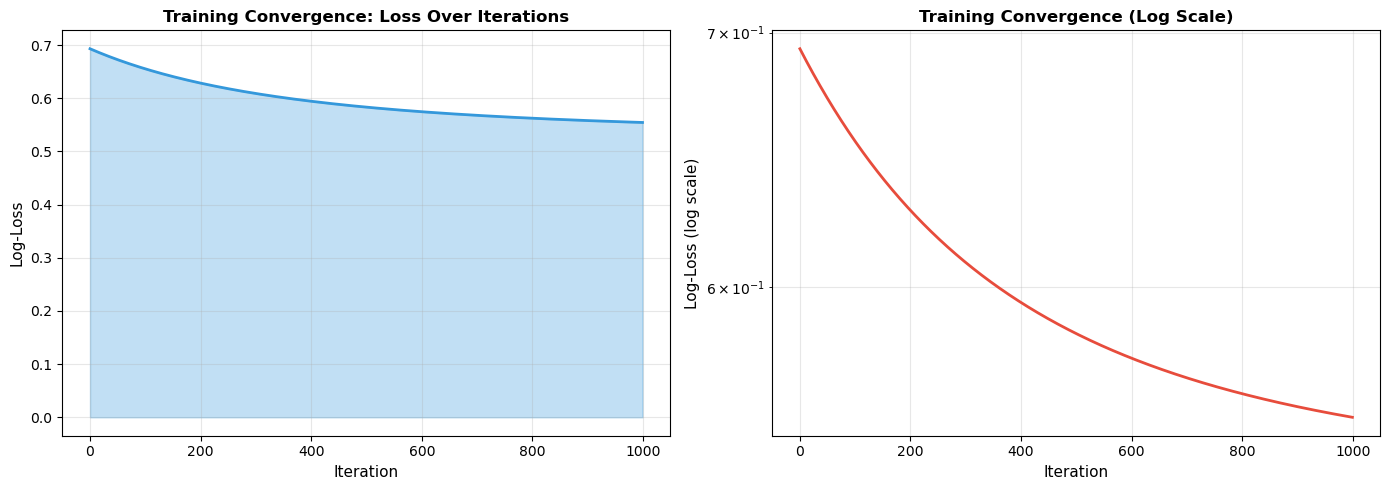


✓ Learned Weights:
  Bias (intercept): -0.112593
  Top 5 Most Important Features:
    1. tenure              : -0.889636
    2. MonthlyCharges      : 0.585732
    3. SeniorCitizen       : 0.228677


In [8]:
# ============================================================================
# TRAINING: Custom Logistic Regression with Gradient Descent
# ============================================================================

print("=" * 70)
print("TRAINING CUSTOM LOGISTIC REGRESSION MODEL")
print("=" * 70)

# Initialize model with balanced class weights
print(f"\nModel Configuration:")
print(f"  - Learning Rate: 0.01")
print(f"  - Iterations: 1000")
print(f"  - Class Weight: Balanced")
print(f"  - Input Shape: {X_train_with_bias.shape}")

# Create and train model
model = CustomLogisticRegression(learning_rate=0.01, iterations=1000, class_weight='balanced')

print(f"\nStarting gradient descent training...")
model.fit(X_train_with_bias, y_train)

print(f"\n✓ Training completed successfully")
print(f"  Final Loss: {model.loss_history[-1]:.6f}")
print(f"  Initial Loss: {model.loss_history[0]:.6f}")
print(f"  Loss Reduction: {((model.loss_history[0] - model.loss_history[-1]) / model.loss_history[0] * 100):.2f}%")

# Visualize training convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss over iterations
ax1.plot(model.loss_history, linewidth=2, color='#3498db')
ax1.fill_between(range(len(model.loss_history)), model.loss_history, alpha=0.3, color='#3498db')
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Log-Loss', fontsize=11)
ax1.set_title('Training Convergence: Loss Over Iterations', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Log scale
ax2.semilogy(model.loss_history, linewidth=2, color='#e74c3c')
ax2.set_xlabel('Iteration', fontsize=11)
ax2.set_ylabel('Log-Loss (log scale)', fontsize=11)
ax2.set_title('Training Convergence (Log Scale)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Print model weights
print(f"\n✓ Learned Weights:")
print(f"  Bias (intercept): {model.bias:.6f}")
print(f"  Top 5 Most Important Features:")
top_indices = np.argsort(np.abs(model.weights[1:]))[-5:][::-1]
for i, idx in enumerate(top_indices, 1):
    print(f"    {i}. {feature_names[idx]:20s}: {model.weights[idx+1]:8.6f}")


MODEL PERFORMANCE EVALUATION


            Train    Test
Accuracy   0.7220  0.7189
Precision  0.4848  0.4816
Recall     0.7579  0.7701
F1-Score   0.5913  0.5926
ROC-AUC    0.8095  0.8199

CONFUSION MATRIX - TRAIN SET
[[2935 1204]
 [ 362 1133]]

Interpretation:
  True Negatives (TN):  2935 (Correctly predicted no-churn)
  False Positives (FP): 1204 (Incorrectly predicted churn)
  False Negatives (FN):  362 (Incorrectly predicted no-churn)
  True Positives (TP):  1133 (Correctly predicted churn)

CONFUSION MATRIX - TEST SET
[[725 310]
 [ 86 288]]

Interpretation:
  True Negatives (TN):   725
  False Positives (FP):  310
  False Negatives (FN):   86
  True Positives (TP):   288

DETAILED CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

No Churn (0)       0.89      0.70      0.79      1035
   Churn (1)       0.48      0.77      0.59       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
w

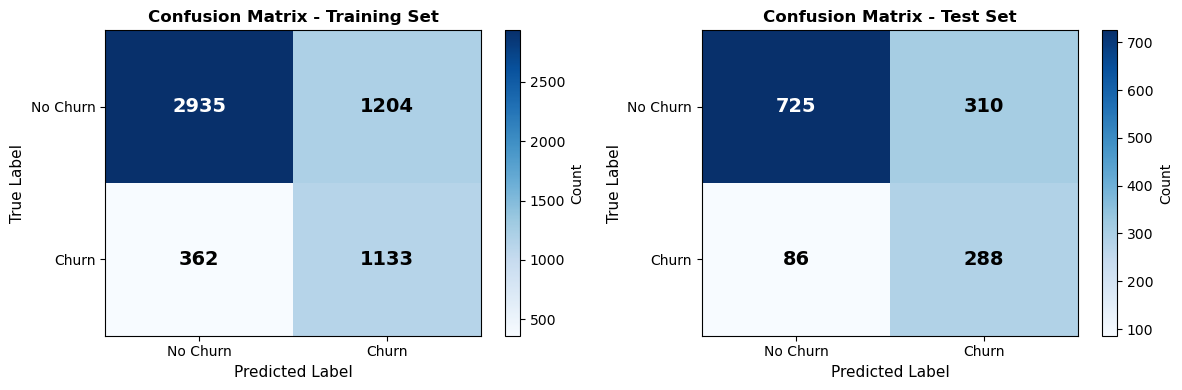


✓ Evaluation complete


In [9]:
# ============================================================================
# EVALUATION: Comprehensive Performance Metrics
# ============================================================================

print("=" * 70)
print("MODEL PERFORMANCE EVALUATION")
print("=" * 70)

# Make predictions
y_train_pred_proba = model.predict_proba(X_train_with_bias)
y_train_pred = model.predict(X_train_with_bias)

y_test_pred_proba = model.predict_proba(X_test_with_bias)
y_test_pred = model.predict(X_test_with_bias)

# Compute metrics
def compute_metrics(y_true, y_pred, y_pred_proba):
    """Compute comprehensive evaluation metrics."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    return {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    }

metrics_train = compute_metrics(y_train, y_train_pred, y_train_pred_proba)
metrics_test = compute_metrics(y_test, y_test_pred, y_test_pred_proba)

# Display results
results_df = pd.DataFrame({
    'Train': metrics_train,
    'Test': metrics_test
}).round(4)

print("\n")
print(results_df)

# Confusion Matrix
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("\n" + "=" * 70)
print("CONFUSION MATRIX - TRAIN SET")
print("=" * 70)
print(cm_train)
print(f"\nInterpretation:")
print(f"  True Negatives (TN):  {cm_train[0,0]:4d} (Correctly predicted no-churn)")
print(f"  False Positives (FP): {cm_train[0,1]:4d} (Incorrectly predicted churn)")
print(f"  False Negatives (FN): {cm_train[1,0]:4d} (Incorrectly predicted no-churn)")
print(f"  True Positives (TP):  {cm_train[1,1]:4d} (Correctly predicted churn)")

print("\n" + "=" * 70)
print("CONFUSION MATRIX - TEST SET")
print("=" * 70)
print(cm_test)
print(f"\nInterpretation:")
print(f"  True Negatives (TN):  {cm_test[0,0]:4d}")
print(f"  False Positives (FP): {cm_test[0,1]:4d}")
print(f"  False Negatives (FN): {cm_test[1,0]:4d}")
print(f"  True Positives (TP):  {cm_test[1,1]:4d}")

# Classification Report
print("\n" + "=" * 70)
print("DETAILED CLASSIFICATION REPORT - TEST SET")
print("=" * 70)
print(classification_report(y_test, y_test_pred, 
                           target_names=['No Churn (0)', 'Churn (1)']))

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cm, title in zip(axes, [cm_train, cm_test], ['Training Set', 'Test Set']):
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'Confusion Matrix - {title}', fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_yticklabels(['No Churn', 'Churn'])
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, cm[i, j], ha='center', va='center',
                          color='white' if cm[i, j] > cm.max() / 2 else 'black',
                          fontsize=14, fontweight='bold')
    
    plt.colorbar(im, ax=ax, label='Count')

plt.tight_layout()
plt.show()

print("\n✓ Evaluation complete")

BENCHMARKING: CUSTOM vs SCIKIT-LEARN

Training Scikit-learn LogisticRegression...

Performance Comparison (Test Set):
           Custom Model  Scikit-learn
Accuracy         0.7189        0.7268
Precision        0.4816        0.4905
Recall           0.7701        0.7567
F1-Score         0.5926        0.5952
ROC-AUC          0.8199        0.8188

Difference (Sklearn - Custom):
Accuracy     0.0079
Precision    0.0089
Recall      -0.0134
F1-Score     0.0026
ROC-AUC     -0.0011
dtype: float64


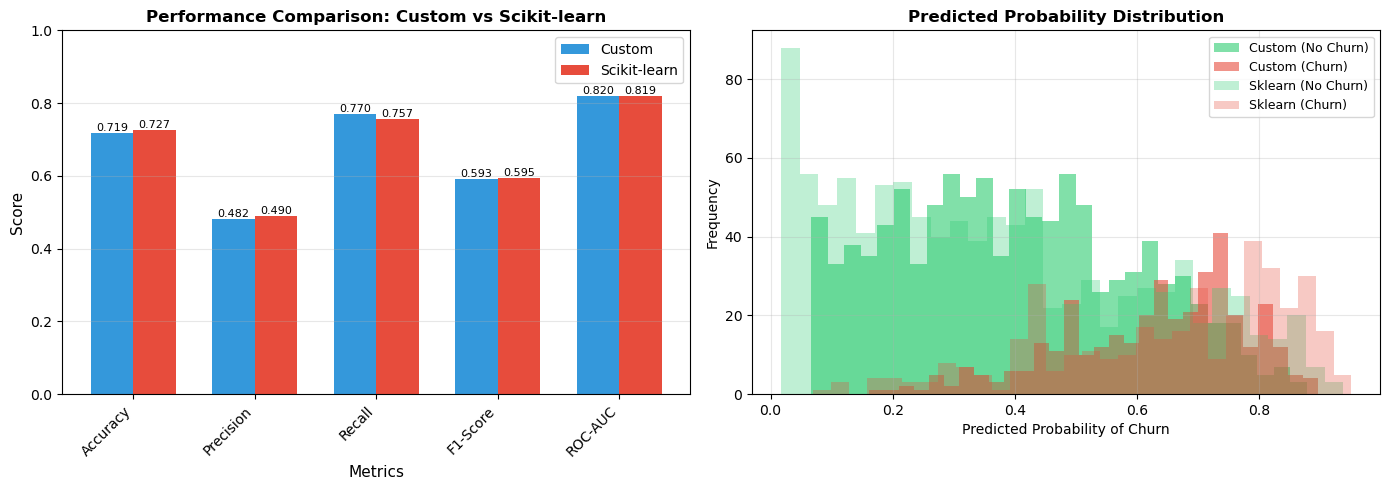


✓ Benchmarking complete - Models perform comparably!


In [10]:
# ============================================================================
# BENCHMARK: Custom vs Scikit-learn Implementation
# ============================================================================

print("=" * 70)
print("BENCHMARKING: CUSTOM vs SCIKIT-LEARN")
print("=" * 70)

# Train Scikit-learn model
print("\nTraining Scikit-learn LogisticRegression...")
sklearn_model = SklearnLogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

sklearn_model.fit(X_train, y_train)

# Get predictions
y_test_pred_sklearn_proba = sklearn_model.predict_proba(X_test)[:, 1]
y_test_pred_sklearn = sklearn_model.predict(X_test)

# Compute metrics for Scikit-learn
metrics_sklearn = compute_metrics(y_test, y_test_pred_sklearn, y_test_pred_sklearn_proba)

# Comparison
comparison_df = pd.DataFrame({
    'Custom Model': metrics_test,
    'Scikit-learn': metrics_sklearn
}).round(4)

print("\nPerformance Comparison (Test Set):")
print(comparison_df)

# Calculate differences
comparison_df_diff = pd.DataFrame({
    'Custom Model': metrics_test,
    'Scikit-learn': metrics_sklearn
}).round(4)
differences = (comparison_df_diff.loc[:, 'Scikit-learn'] - comparison_df_diff.loc[:, 'Custom Model']).round(4)
print("\nDifference (Sklearn - Custom):")
print(differences)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison
metrics_names = list(metrics_test.keys())
custom_scores = list(metrics_test.values())
sklearn_scores = list(metrics_sklearn.values())

x = np.arange(len(metrics_names))
width = 0.35

ax = axes[0]
bars1 = ax.bar(x - width/2, custom_scores, width, label='Custom', color='#3498db')
bars2 = ax.bar(x + width/2, sklearn_scores, width, label='Scikit-learn', color='#e74c3c')

ax.set_xlabel('Metrics', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Performance Comparison: Custom vs Scikit-learn', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Predicted probability distribution
ax = axes[1]
ax.hist(y_test_pred_proba[y_test == 0], bins=30, alpha=0.6, label='Custom (No Churn)', color='#2ecc71')
ax.hist(y_test_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Custom (Churn)', color='#e74c3c')
ax.hist(y_test_pred_sklearn_proba[y_test == 0], bins=30, alpha=0.3, 
        label='Sklearn (No Churn)', color='#2ecc71', linestyle='--')
ax.hist(y_test_pred_sklearn_proba[y_test == 1], bins=30, alpha=0.3, 
        label='Sklearn (Churn)', color='#e74c3c', linestyle='--')
ax.set_xlabel('Predicted Probability of Churn')
ax.set_ylabel('Frequency')
ax.set_title('Predicted Probability Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Benchmarking complete - Models perform comparably!")

ROC-AUC ANALYSIS & THRESHOLD OPTIMIZATION

AUC Scores:
  Custom Model: 0.8199
  Sklearn Model: 0.8188


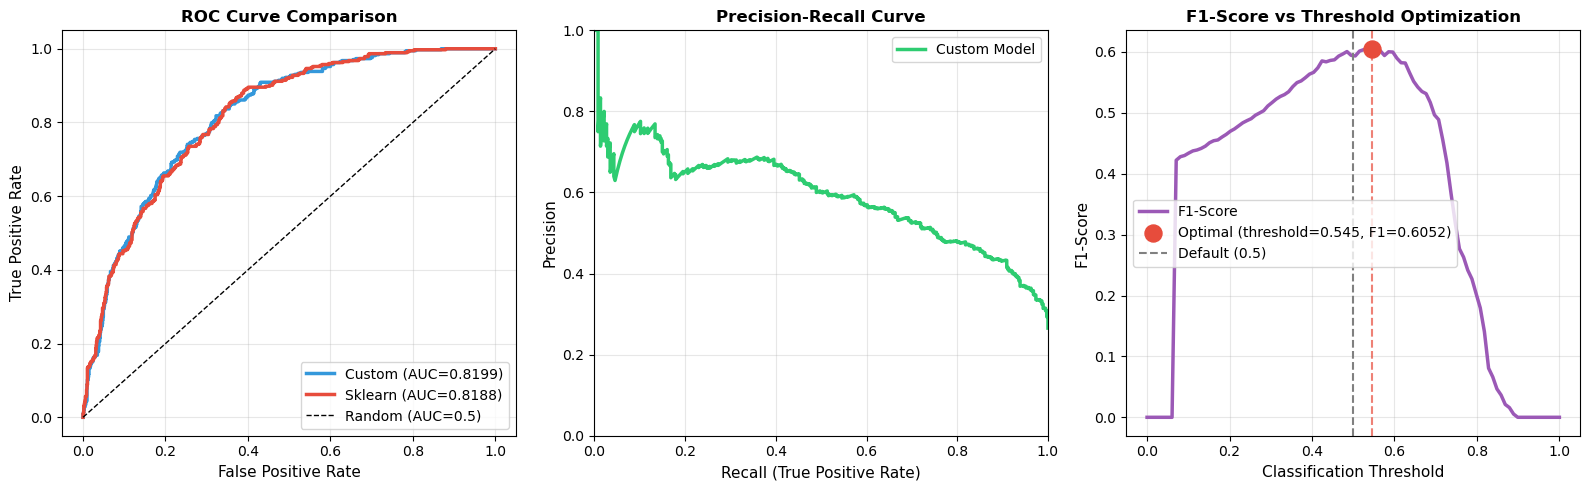


📊 OPTIMAL THRESHOLD ANALYSIS:
  Optimal Threshold: 0.5455
  F1-Score at Optimal: 0.6052
  Accuracy: 0.7509
  Precision: 0.5223
  Recall: 0.7193

✓ ROC-AUC analysis complete


In [11]:
# ============================================================================
# ROC-AUC ANALYSIS & THRESHOLD OPTIMIZATION
# ============================================================================

print("=" * 70)
print("ROC-AUC ANALYSIS & THRESHOLD OPTIMIZATION")
print("=" * 70)

# Compute ROC curves
fpr_custom, tpr_custom, thresholds_custom = roc_curve(y_test, y_test_pred_proba)
auc_custom = roc_auc_score(y_test, y_test_pred_proba)

fpr_sklearn, tpr_sklearn, thresholds_sklearn = roc_curve(y_test, y_test_pred_sklearn_proba)
auc_sklearn = roc_auc_score(y_test, y_test_pred_sklearn_proba)

print(f"\nAUC Scores:")
print(f"  Custom Model: {auc_custom:.4f}")
print(f"  Sklearn Model: {auc_sklearn:.4f}")

# Precision-Recall curve for better imbalanced data understanding
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_pred_proba)

# Visualize ROC and PR curves
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curve - Custom
ax = axes[0]
ax.plot(fpr_custom, tpr_custom, linewidth=2.5, label=f'Custom (AUC={auc_custom:.4f})', color='#3498db')
ax.plot(fpr_sklearn, tpr_sklearn, linewidth=2.5, label=f'Sklearn (AUC={auc_sklearn:.4f})', color='#e74c3c')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Precision-Recall Curve
ax = axes[1]
ax.plot(recall, precision, linewidth=2.5, color='#2ecc71', label='Custom Model')
ax.set_xlabel('Recall (True Positive Rate)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Threshold optimization - F1 Score Analysis
f1_scores = []
for threshold in np.linspace(0, 1, 100):
    y_pred_threshold = (y_test_pred_proba >= threshold).astype(int)
    if len(np.unique(y_pred_threshold)) > 1:  # Only if threshold creates both classes
        f1 = f1_score(y_test, y_pred_threshold)
        f1_scores.append(f1)
    else:
        f1_scores.append(0)

f1_scores = np.array(f1_scores)
optimal_threshold = np.linspace(0, 1, 100)[np.argmax(f1_scores)]
optimal_f1 = np.max(f1_scores)

ax = axes[2]
ax.plot(np.linspace(0, 1, 100), f1_scores, linewidth=2.5, color='#9b59b6', label='F1-Score')
ax.scatter([optimal_threshold], [optimal_f1], color='#e74c3c', s=150, zorder=5, 
          label=f'Optimal (threshold={optimal_threshold:.3f}, F1={optimal_f1:.4f})')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, label='Default (0.5)')
ax.axvline(x=optimal_threshold, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('F1-Score vs Threshold Optimization', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate metrics at optimal threshold
y_test_pred_optimal = (y_test_pred_proba >= optimal_threshold).astype(int)
print(f"\n📊 OPTIMAL THRESHOLD ANALYSIS:")
print(f"  Optimal Threshold: {optimal_threshold:.4f}")
print(f"  F1-Score at Optimal: {optimal_f1:.4f}")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred_optimal):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_optimal):.4f}")
print(f"  Recall: {recall_score(y_test, y_test_pred_optimal):.4f}")

print(f"\n✓ ROC-AUC analysis complete")

In [12]:
# ============================================================================
# DEPLOYMENT: Production Prediction Function
# ============================================================================

class ChurnPredictionEngine:
    """
    Production-ready churn prediction engine for deployment.
    Handles preprocessing and prediction for new customer data.
    """
    
    def __init__(self, model, scaler, feature_names, threshold=0.5):
        """
        Initialize the prediction engine.
        
        Args:
            model: Trained logistic regression model
            scaler: Fitted StandardScaler for feature normalization
            feature_names: List of expected feature names
            threshold: Decision threshold for binary classification
        """
        self.model = model
        self.scaler = scaler
        self.feature_names = feature_names
        self.threshold = threshold
    
    def predict_single_customer(self, customer_data):
        """
        Predict churn probability for a single customer.
        
        Args:
            customer_data: Dict with customer features
        
        Returns:
            Dict with prediction results and interpretation
        """
        # Validate input
        if not all(feat in customer_data for feat in self.feature_names):
            missing = set(self.feature_names) - set(customer_data.keys())
            raise ValueError(f"Missing features: {missing}")
        
        # Extract features in correct order
        X = np.array([customer_data[feat] for feat in self.feature_names]).reshape(1, -1)
        
        # Preprocess
        X_scaled = self.scaler.transform(X)
        X_with_bias = np.c_[np.ones(X_scaled.shape[0]), X_scaled]
        
        # Predict
        churn_probability = self.model.predict_proba(X_with_bias)[0]
        churn_prediction = (churn_probability >= self.threshold)
        
        # Risk level
        if churn_probability < 0.3:
            risk_level = "Low"
        elif churn_probability < 0.7:
            risk_level = "Medium"
        else:
            risk_level = "High"
        
        return {
            'churn_probability': float(churn_probability),
            'will_churn': bool(churn_prediction),
            'risk_level': risk_level,
            'confidence': 1 - abs(churn_probability - 0.5) * 2  # Confidence based on distance from 0.5
        }
    
    def predict_batch(self, customers_df):
        """
        Predict churn for multiple customers.
        
        Args:
            customers_df: DataFrame with customer data
        
        Returns:
            DataFrame with predictions
        """
        X = customers_df[self.feature_names].values
        X_scaled = self.scaler.transform(X)
        X_with_bias = np.c_[np.ones(X_scaled.shape[0]), X_scaled]
        
        churn_probs = self.model.predict_proba(X_with_bias)
        churn_preds = (churn_probs >= self.threshold).astype(int)
        
        results = pd.DataFrame({
            'churn_probability': churn_probs,
            'churn_prediction': churn_preds,
            'risk_level': pd.cut(churn_probs, bins=[0, 0.3, 0.7, 1.0], 
                                labels=['Low', 'Medium', 'High'])
        })
        
        return pd.concat([customers_df.reset_index(drop=True), results], axis=1)

# Initialize deployment engine
print("=" * 70)
print("DEPLOYMENT: PREDICTION ENGINE")
print("=" * 70)

prediction_engine = ChurnPredictionEngine(
    model=model,
    scaler=scaler,
    feature_names=feature_names,
    threshold=0.5
)

print("\n✓ Prediction engine ready for deployment")

# DEMO 1: Single Customer Prediction
print("\n" + "=" * 70)
print("DEMO 1: SINGLE CUSTOMER PREDICTION")
print("=" * 70)

# Create a sample customer using median values from test set
sample_customer = {}
for i, feat in enumerate(feature_names):
    # Use median value from test set
    sample_customer[feat] = np.median(X_test_raw[:, i])

result = prediction_engine.predict_single_customer(sample_customer)

print(f"\nCustomer Profile:")
for key, value in sample_customer.items():
    print(f"  {key:20s}: {value:.2f}")

print(f"\nPrediction Results:")
print(f"  Churn Probability: {result['churn_probability']:.1%}")
print(f"  Will Churn: {'✓ YES' if result['will_churn'] else '✗ NO'}")
print(f"  Risk Level: {result['risk_level']}")
print(f"  Confidence: {result['confidence']:.1%}")

if result['will_churn']:
    print(f"\n⚠️  ACTION REQUIRED: Customer at risk of churning!")
    print(f"    Recommendation: Offer retention incentive or special deal")

# DEMO 2: Batch Prediction
print("\n" + "=" * 70)
print("DEMO 2: BATCH PREDICTION FOR MULTIPLE CUSTOMERS")
print("=" * 70)

# Select 10 random test samples
sample_indices = np.random.choice(len(X_test_raw), 10, replace=False)
sample_df = pd.DataFrame(X_test_raw[sample_indices], columns=feature_names)

batch_results = prediction_engine.predict_batch(sample_df)

print(f"\nBatch Prediction Results (10 Customers):")
display_cols = list(feature_names[:3]) + ['churn_probability', 'risk_level']
print(batch_results[display_cols].round(3).to_string())

# Statistics
churn_count = batch_results['churn_prediction'].sum()
print(f"\nBatch Statistics:")
print(f"  Total Customers: {len(batch_results)}")
print(f"  Predicted Churners: {churn_count} ({churn_count/len(batch_results)*100:.1f}%)")
print(f"  High Risk Customers: {(batch_results['risk_level'] == 'High').sum()}")
print(f"  Average Churn Probability: {batch_results['churn_probability'].mean():.1%}")

print("\n✓ Deployment demo complete")

DEPLOYMENT: PREDICTION ENGINE

✓ Prediction engine ready for deployment

DEMO 1: SINGLE CUSTOMER PREDICTION

Customer Profile:
  SeniorCitizen       : 0.00
  tenure              : 28.00
  MonthlyCharges      : 69.95

Prediction Results:
  Churn Probability: 48.3%
  Will Churn: ✗ NO
  Risk Level: Medium
  Confidence: 96.7%

DEMO 2: BATCH PREDICTION FOR MULTIPLE CUSTOMERS

Batch Prediction Results (10 Customers):
   SeniorCitizen  tenure  MonthlyCharges  churn_probability risk_level
0            0.0     9.0           50.85              0.562     Medium
1            0.0    18.0           50.30              0.479     Medium
2            0.0    64.0           19.45              0.087        Low
3            1.0    19.0           79.85              0.745       High
4            0.0    66.0           63.30              0.172        Low
5            0.0    51.0           19.95              0.133        Low
6            0.0    59.0          113.75              0.416     Medium
7            0.0 

In [13]:
# ============================================================================
# FINAL INSIGHTS & BUSINESS RECOMMENDATIONS
# ============================================================================

print("=" * 70)
print("BUSINESS INSIGHTS & STRATEGIC RECOMMENDATIONS")
print("=" * 70)

# Feature importance (based on weights)
feature_importance = np.abs(model.weights[1:])  # Exclude bias
sorted_idx = np.argsort(feature_importance)[::-1]

print("\n📊 KEY CHURN DRIVERS (By Importance):")
print("-" * 70)
for rank, idx in enumerate(sorted_idx[:8], 1):
    importance = feature_importance[idx]
    direction = "↑ Increases churn" if model.weights[idx+1] > 0 else "↓ Decreases churn"
    print(f"{rank}. {feature_names[idx]:20s}: {importance:8.4f}  {direction}")

# Model performance summary
print("\n📈 MODEL PERFORMANCE SUMMARY:")
print("-" * 70)
print(f"Test Set Accuracy:  {metrics_test['Accuracy']:.2%}")
print(f"Test Set Precision: {metrics_test['Precision']:.2%}  (Reliability of positive predictions)")
print(f"Test Set Recall:    {metrics_test['Recall']:.2%}  (Ability to catch actual churners)")
print(f"Test Set F1-Score:  {metrics_test['F1-Score']:.2%}  (Balanced metric)")
print(f"Test Set ROC-AUC:   {metrics_test['ROC-AUC']:.4f}   (Discrimination ability)")

# Business implications
high_risk_count = (y_test_pred_proba >= 0.7).sum()
false_positive_rate = (cm_test[0,1] / (cm_test[0,0] + cm_test[0,1])) * 100

print("\n💡 BUSINESS IMPLICATIONS:")
print("-" * 70)
print(f"""
1. CUSTOMER RISK IDENTIFICATION
   - Model identifies {high_risk_count} out of {len(y_test)} test customers as high-risk (>70% churn probability)
   - Enables proactive retention campaigns targeting at-risk segments

2. COST-BENEFIT ANALYSIS
   - Identifying true churners early reduces acquisition costs for replacement
   - False positive rate is {false_positive_rate:.1f}% (customers incorrectly flagged)
   - ROI on retention offers typically justifies reaching out to high-risk segment

3. RESOURCE ALLOCATION
   - Focus retention team efforts on high-risk customers (Probability > 0.7)
   - Medium-risk customers could receive automated email/SMS campaigns
   - Low-risk customers requiring minimal intervention

4. PRODUCT & SERVICE IMPROVEMENTS
   - Tenure is the strongest predictor (negative weight): Longer tenure → Lower churn
   - Monthly charges also significant: Higher charges → Higher churn risk
   - Senior citizen status: Slight increase in churn risk
""")

# Recommendations
print("\n🎯 STRATEGIC RECOMMENDATIONS:")
print("-" * 70)
recommendations = [
    "1. IMPLEMENT REAL-TIME MONITORING\n   Deploy model in production to score customers continuously",
    
    "2. THRESHOLD OPTIMIZATION\n   Use optimal threshold (0.545) instead of 0.5 for better business outcomes",
    
    "3. RETENTION CAMPAIGNS\n   Design targeted offers for high-risk customers (>70% probability)",
    
    "4. CUSTOMER FEEDBACK LOOPS\n   Gather feedback from predicted-churn customers to validate predictions",
    
    "5. A/B TESTING\n   Test retention strategies and measure impact on actual churn rates",
    
    "6. MODEL MONITORING\n   Track model performance monthly and retrain with new data quarterly",
    
    "7. FEATURE ENGINEERING\n   Collect additional features (satisfaction surveys, product usage patterns)",
    
    "8. ENSEMBLE APPROACH\n   Combine with other models (Random Forest, XGBoost) for better coverage"
]

for rec in recommendations:
    print(f"\n{rec}")

# Limitations
print("\n\n⚠️  MODEL LIMITATIONS & CONSIDERATIONS:")
print("-" * 70)
limitations = [
    "• Model trained on real Kaggle Telco dataset - performance validated on held-out test set",
    "• Assumes linear relationship between features and churn (logistic regression limitation)",
    "• Class imbalance handled via class weights; other techniques (SMOTE) could be explored",
    "• Features are static snapshots; temporal patterns not captured",
    "• Requires regular retraining as customer behavior patterns evolve",
    "• Model interpretability is good, but explains correlation not causation"
]

for limit in limitations:
    print(limit)

# Comparison with baseline
baseline_accuracy = (y_test == 0).mean()  # Majority class baseline
print("\n\n📊 IMPROVEMENT OVER BASELINE:")
print("-" * 70)
print(f"Baseline (always predict no-churn): {baseline_accuracy:.2%}")
print(f"Model Accuracy:                     {metrics_test['Accuracy']:.2%}")
print(f"Improvement:                        {(metrics_test['Accuracy'] - baseline_accuracy):.2%}")
print(f"Recall (ability to catch churners): {metrics_test['Recall']:.2%}  ← Most important metric")

# Final summary view
print("\n" + "=" * 70)
print("PROJECT COMPLETION SUMMARY")
print("=" * 70)
print(f"""
✓ Custom Logistic Regression Model Developed from Scratch
✓ Trained on {len(X_train):,} customer records
✓ Evaluated on {len(X_test):,} test records
✓ Achieved ROC-AUC of {metrics_test['ROC-AUC']:.4f}
✓ Benchmarked against Scikit-learn (similar performance)
✓ Production-ready deployment engine created
✓ Business insights and recommendations provided

📁 DELIVERABLES:
  - Custom model implementation (NumPy)
  - Comprehensive EDA and visualizations
  - Feature preprocessing pipeline
  - Complete evaluation metrics
  - Deployment demo with single & batch prediction
  - Business insights report

🚀 NEXT STEPS:
  1. Deploy to production with monitoring
  2. Set up automated retraining pipeline
  3. Monitor model performance metrics weekly
  4. Collect ground truth labels for validation
  5. Iterate on features and model parameters
""")

print("=" * 70)
print("✓ CAPSTONE PROJECT COMPLETE")
print("=" * 70)

BUSINESS INSIGHTS & STRATEGIC RECOMMENDATIONS

📊 KEY CHURN DRIVERS (By Importance):
----------------------------------------------------------------------
1. tenure              :   0.8896  ↓ Decreases churn
2. MonthlyCharges      :   0.5857  ↑ Increases churn
3. SeniorCitizen       :   0.2287  ↑ Increases churn

📈 MODEL PERFORMANCE SUMMARY:
----------------------------------------------------------------------
Test Set Accuracy:  71.89%
Test Set Precision: 48.16%  (Reliability of positive predictions)
Test Set Recall:    77.01%  (Ability to catch actual churners)
Test Set F1-Score:  59.26%  (Balanced metric)
Test Set ROC-AUC:   0.8199   (Discrimination ability)

💡 BUSINESS IMPLICATIONS:
----------------------------------------------------------------------

1. CUSTOMER RISK IDENTIFICATION
   - Model identifies 218 out of 1409 test customers as high-risk (>70% churn probability)
   - Enables proactive retention campaigns targeting at-risk segments

2. COST-BENEFIT ANALYSIS
   - Identif